# BTC 1D — Experimento exp10_close_only

Objetivo: predicción de **Close** (1D) con Transformer encoder-only.

Se entrena en espacio relativo: se predice el **log-ratio** del close futuro respecto al close actual y luego se reconstruye a nivel de precio.


In [19]:
import sys, subprocess, importlib
packages = ["pandas","numpy","matplotlib","scikit-learn","torch","joblib","tqdm"]
for p in packages:
    try:
        importlib.import_module(p if p != "scikit-learn" else "sklearn")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p])

import json
import math
import random
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib


## Datos y rutas

Se busca automáticamente el CSV dentro del repo y se crean las carpetas de salida del experimento.


In [20]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def find_repo_root():
    start = pathlib.Path(".").resolve()
    for p in [start] + list(start.parents):
        if (p / "experimentos" / "data" / "btc_binance_ohlcv_1d.csv").exists():
            return p
    raise FileNotFoundError(f"No se encontró el repo raíz desde: {start}")

repo_root = find_repo_root()

csv_candidates = [
    repo_root / "experimentos" / "data" / "btc_binance_ohlcv_1d.csv",
]
csv_path = next((p for p in csv_candidates if p.exists()), csv_candidates[0])
if not csv_path.exists():
    raise FileNotFoundError(f"No existe el CSV. Probado: {csv_candidates}")

exp_root = repo_root / "experimentos"
models_root = exp_root / "modelos"
preds_root = exp_root / "predicciones"
figures_root = exp_root / "figuras"

for p in [models_root, preds_root, figures_root]:
    p.mkdir(parents=True, exist_ok=True)

csv_path


PosixPath('/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/experimentos/data/btc_binance_ohlcv_1d.csv')

## Carga y features

Se usa el mismo set de features que en los experimentos OHLCV (para poder comparar), pero el target es solo `close`.


In [21]:
df = pd.read_csv(csv_path)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

df["range_hl"] = (df["high"] - df["low"]).astype(np.float32)
df["body_co"] = (df["close"] - df["open"]).astype(np.float32)
df["abs_log_return"] = df["log_return"].abs().astype(np.float32)
df["log_volume"] = np.log1p(df["volume"]).astype(np.float32)
df["day_of_week"] = df["timestamp"].dt.dayofweek.astype(np.int16)

feature_cols = [
    "open","high","low","close","volume",
    "log_close","log_return",
    "range_hl","body_co","abs_log_return","log_volume","day_of_week",
    "sma_8","ema_8","sma_20","ema_20",
    "sma_100","ema_100","sma_200","ema_200",
    "volatility_7"
]

target_col = "close"

df = df.dropna(subset=feature_cols).reset_index(drop=True)
df.shape


(2910, 22)

## Secuencias (window → horizon)

Se construye `X` con una ventana de `window` días y un `y` a `horizon` días.


In [22]:
def build_sequences_close(features, close_abs, timestamps, close_series, window, horizon):
    X, y_close_abs, y_dates, close_t = [], [], [], []
    last_index = len(features) - horizon
    for idx in range(window - 1, last_index):
        X.append(features[idx - window + 1: idx + 1])
        y_close_abs.append(close_abs[idx + horizon])
        y_dates.append(timestamps[idx + horizon])
        close_t.append(close_series[idx])
    return np.array(X), np.array(y_close_abs), np.array(y_dates), np.array(close_t)


## Métricas

Se reporta el error en **precio (close)** y también en **log-retorno** del close (incluye direccionalidad).


In [23]:
def mae_1d(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse_1d(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def directional_acc_1d(y_true, y_pred):
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))

def metrics_log_return(y_true, y_pred):
    return {
        "mae": mae_1d(y_true, y_pred),
        "rmse": rmse_1d(y_true, y_pred),
        "directional_acc": directional_acc_1d(y_true, y_pred),
    }

def metrics_close_abs(y_true, y_pred):
    return {"mae": mae_1d(y_true, y_pred), "rmse": rmse_1d(y_true, y_pred)}


## Modelo

Transformer encoder-only: proyección lineal → codificación posicional → `n_layers` bloques de self-attention.

Salida: 1 dimensión (close) en espacio relativo (log-ratio).


In [24]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerRegressor(nn.Module):
    def __init__(self, n_features, out_dim=1, d_model=64, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=512)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.regressor = nn.Linear(d_model, out_dim)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        return self.regressor(x)

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


## Configuración del experimento


In [25]:
cfg = {
  "run_tag": "exp10_close_only",
  "window": 14,
  "horizon": 1,
  "batch_size": 64,
  "epochs": 200,
  "patience": 15,
  "min_epochs": 30,
  "min_delta": 1e-4,
  "reset_patience_on_lr_drop": True,
  "lr_patience": 6,
  "lr_factor": 0.5,
  "d_model": 64,
  "n_heads": 4,
  "n_layers": 4,
  "dropout": 0.1,
  "lr": 5e-4
}


## Entrenamiento y evaluación

Los logs se imprimen por epoch y se guardan figuras y métricas por experimento.

### 1) Directorios y parámetros

Se definen hiperparámetros desde `cfg` y rutas de salida (modelos/predicciones/figuras).


In [26]:
run_tag = cfg["run_tag"]
window = int(cfg.get("window", 7))
horizon = int(cfg.get("horizon", 1))

batch_size = int(cfg.get("batch_size", 64))
epochs = int(cfg.get("epochs", 100))
patience = int(cfg.get("patience", 10))
min_epochs = int(cfg.get("min_epochs", 20))
min_delta = float(cfg.get("min_delta", 1e-4))
reset_patience_on_lr_drop = bool(cfg.get("reset_patience_on_lr_drop", True))
lr_patience = int(cfg.get("lr_patience", 5))
lr_factor = float(cfg.get("lr_factor", 0.5))

d_model = int(cfg.get("d_model", 64))
n_heads = int(cfg.get("n_heads", 4))
n_layers = int(cfg.get("n_layers", 2))
dropout = float(cfg.get("dropout", 0.1))
lr = float(cfg.get("lr", 1e-3))

run_dirs = {
    "models": models_root / run_tag,
    "predictions": preds_root / run_tag,
    "figures": figures_root / run_tag,
}
for p in run_dirs.values():
    p.mkdir(parents=True, exist_ok=True)

model_path = run_dirs["models"] / "transformer_btc_1d_close.pt"
scaler_path = run_dirs["models"] / "scaler_x_btc_1d_close.joblib"
y_scaler_path = run_dirs["models"] / "scaler_y_btc_1d_close.joblib"
config_path = run_dirs["models"] / "config_transformer_btc_1d_close.json"
metrics_path = run_dirs["models"] / "metrics_transformer_btc_1d_close.json"
preds_csv_path = run_dirs["predictions"] / "btc_1d_transformer_close_test_predictions.csv"

print("Run:", run_tag)
print("HParams:", {"window": window, "horizon": horizon, "d_model": d_model, "n_heads": n_heads, "n_layers": n_layers, "dropout": dropout, "lr": lr})
print("Train:", {"batch_size": batch_size, "epochs": epochs, "patience": patience, "min_epochs": min_epochs})
run_dirs


Run: exp10_close_only
HParams: {'window': 14, 'horizon': 1, 'd_model': 64, 'n_heads': 4, 'n_layers': 4, 'dropout': 0.1, 'lr': 0.0005}
Train: {'batch_size': 64, 'epochs': 200, 'patience': 15, 'min_epochs': 30}


{'models': PosixPath('/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/experimentos/modelos/exp10_close_only'),
 'predictions': PosixPath('/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/experimentos/predicciones/exp10_close_only'),
 'figures': PosixPath('/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/experimentos/figuras/exp10_close_only')}

### 2) Construcción de secuencias y split temporal

Se genera `X_all` con ventana `window` y target a `horizon` días. Luego se hace split cronológico: 70% train, 15% val, 15% test.


In [27]:
features = df[feature_cols].values.astype(np.float32)
close_abs = df[target_col].values.astype(np.float32)
timestamps = df["timestamp"].values
close_series = df["close"].values.astype(np.float32)

X_all, y_all_close_abs, y_dates_all, close_t_all = build_sequences_close(
    features, close_abs, timestamps, close_series, window=window, horizon=horizon
)

eps = 1e-6
y_all_close_rel = np.log((y_all_close_abs + eps) / (close_t_all + eps)).astype(np.float32)

n_total = len(X_all)
train_size = int(n_total * 0.7)
val_size = int(n_total * 0.15)
test_size = n_total - train_size - val_size

X_train_raw = X_all[:train_size]
y_train_abs = y_all_close_abs[:train_size]
y_train_rel = y_all_close_rel[:train_size]

X_val_raw = X_all[train_size:train_size + val_size]
y_val_rel = y_all_close_rel[train_size:train_size + val_size]

X_test_raw = X_all[train_size + val_size:]
y_test_abs = y_all_close_abs[train_size + val_size:]
y_test_rel = y_all_close_rel[train_size + val_size:]
y_dates_test = y_dates_all[train_size + val_size:]
close_t_test = close_t_all[train_size + val_size:]

{
  "n_total": n_total,
  "train": len(X_train_raw),
  "val": len(X_val_raw),
  "test": len(X_test_raw),
}


{'n_total': 2896, 'train': 2027, 'val': 434, 'test': 435}

### 3) Escalado (X e y) y DataLoaders

Se ajustan los `StandardScaler` con train y se aplican a val/test. `y` se entrena en espacio relativo y escalado.


In [28]:
scaler = StandardScaler()
scaler.fit(X_train_raw.reshape(-1, X_train_raw.shape[-1]))

def scale_X(X):
    X_2d = X.reshape(-1, X.shape[-1])
    return scaler.transform(X_2d).reshape(X.shape)

X_train = scale_X(X_train_raw)
X_val = scale_X(X_val_raw)
X_test = scale_X(X_test_raw)

y_scaler = StandardScaler()
y_scaler.fit(y_train_rel.reshape(-1, 1))

y_train = y_scaler.transform(y_train_rel.reshape(-1, 1)).astype(np.float32)
y_val = y_scaler.transform(y_val_rel.reshape(-1, 1)).astype(np.float32)
y_test = y_scaler.transform(y_test_rel.reshape(-1, 1)).astype(np.float32)

joblib.dump(scaler, scaler_path)
joblib.dump(y_scaler, y_scaler_path)

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(SeqDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(SeqDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

{
  "X_train": X_train.shape,
  "y_train": y_train.shape,
}


{'X_train': (2027, 14, 21), 'y_train': (2027, 1)}

### 4) Modelo y criterio

Se crea el Transformer y se usa Huber (SmoothL1) sobre la salida escalar.


In [29]:
model = TransformerRegressor(
    n_features=X_train.shape[-1],
    out_dim=1,
    d_model=d_model,
    n_heads=n_heads,
    n_layers=n_layers,
    dropout=dropout,
).to(device)

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=lr_factor, patience=lr_patience
)

sum(p.numel() for p in model.parameters())


1126081

### 5) Entrenamiento (con early stopping)

Se entrena por epochs, se evalúa en validación y se guarda el mejor estado por `val_loss`.


In [30]:
train_losses = []
val_losses = []
best_val = float("inf")
best_state = None
patience_counter = 0

for epoch in range(epochs):
    model.train()
    total_train = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_train += loss.item() * xb.size(0)

    train_loss = total_train / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            total_val += loss.item() * xb.size(0)

    val_loss = total_val / len(val_loader.dataset)
    val_losses.append(val_loss)

    lr_prev = float(optimizer.param_groups[0]["lr"])
    scheduler.step(val_loss)
    lr_now = float(optimizer.param_groups[0]["lr"])
    lr_reduced = lr_now < lr_prev

    improved = val_loss < (best_val - min_delta)
    if improved:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        if (epoch + 1) >= min_epochs:
            patience_counter += 1

    if lr_reduced and reset_patience_on_lr_drop and (epoch + 1) >= min_epochs:
        patience_counter = 0

    print(
        f"Epoch {epoch+1:03d} | train={train_loss:.6f} | val={val_loss:.6f} | lr={lr_now:.6g} | best_val={best_val:.6f} | patience={patience_counter}/{patience}"
        + (" | lr↓" if lr_reduced else "")
        + (" | *" if improved else "")
    )

    if (epoch + 1) >= min_epochs and patience_counter >= patience:
        print("Early stopping")
        break


Epoch 001 | train=0.479449 | val=0.252609 | lr=0.0005 | best_val=0.252609 | patience=0/15 | *
Epoch 002 | train=0.353982 | val=0.247067 | lr=0.0005 | best_val=0.247067 | patience=0/15 | *
Epoch 003 | train=0.352089 | val=0.234644 | lr=0.0005 | best_val=0.234644 | patience=0/15 | *
Epoch 004 | train=0.352138 | val=0.232920 | lr=0.0005 | best_val=0.232920 | patience=0/15 | *


KeyboardInterrupt: 

### 6) Guardado del mejor modelo y curva de pérdida


In [ ]:
if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), model_path)

fig_loss, ax = plt.subplots(figsize=(8,4))
ax.plot(train_losses, label="train")
ax.plot(val_losses, label="val")
ax.set_title("Pérdida")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
fig_loss.tight_layout()
fig_path_loss = run_dirs["figures"] / "btc_transformer_close_train_val_loss.png"
fig_loss.savefig(fig_path_loss, dpi=300, bbox_inches="tight")
plt.close(fig_loss)

fig_path_loss


PosixPath('/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/experimentos/figuras/exp10_close_only/btc_transformer_close_train_val_loss.png')

### 7) Predicción en test y reconstrucción del Close

Se invierte el escalado de `y`, se reconstruye a niveles absolutos y se calcula el log-retorno del close predicho.


In [ ]:
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        preds.append(pred)

y_pred_scaled = np.concatenate(preds).reshape(-1, 1)
y_pred_rel = y_scaler.inverse_transform(y_pred_scaled).reshape(-1)

y_pred_close_abs = (close_t_test * np.exp(y_pred_rel)).astype(np.float32)

y_true_logret = y_test_rel
y_pred_logret = y_pred_rel

{
  "y_pred_close_abs": y_pred_close_abs.shape,
  "y_pred_logret": y_pred_logret.shape,
}


{'y_pred_close_abs': (435,), 'y_pred_logret': (435,)}

### 8) Métricas (modelo y baselines)

Se compara contra baselines simples:
- **close persistence**: predice close(t+h) = close(t)
- **close linear**: regresión lineal sobre la ventana (flatten)
- **logret zero**: predice logret=0
- **logret persistence**: usa `log_return` del último día
- **logret linear**: regresión lineal sobre la ventana para logret


In [ ]:
model_metrics_close = metrics_close_abs(y_test_abs, y_pred_close_abs)
model_metrics_logret = metrics_log_return(y_true_logret, y_pred_logret)

y_pred_close_persist = close_t_test.copy()

X_train_lr = X_train.reshape(X_train.shape[0], -1)
X_test_lr = X_test.reshape(X_test.shape[0], -1)

lr_model_close = LinearRegression()
lr_model_close.fit(X_train_lr, y_train_abs)
y_pred_close_lr = lr_model_close.predict(X_test_lr).astype(np.float32)

baseline_metrics_close = {
    "test_close_persistence": metrics_close_abs(y_test_abs, y_pred_close_persist),
    "test_close_linear": metrics_close_abs(y_test_abs, y_pred_close_lr),
}

y_pred_logret_zero = np.zeros_like(y_true_logret)
log_return_idx = feature_cols.index("log_return")
y_pred_logret_persist = X_test_raw[:, -1, log_return_idx]

lr_model_logret = LinearRegression()
lr_model_logret.fit(X_train_lr, y_train_rel)
y_pred_logret_lr = lr_model_logret.predict(X_test_lr).astype(np.float32)

baseline_metrics_logret = {
    "test_logret_zero": metrics_log_return(y_true_logret, y_pred_logret_zero),
    "test_logret_persistence": metrics_log_return(y_true_logret, y_pred_logret_persist),
    "test_logret_linear": metrics_log_return(y_true_logret, y_pred_logret_lr),
}

model_metrics_logret, model_metrics_close


({'mae': 0.0163362305611372,
  'rmse': 0.02362632565200329,
  'directional_acc': 0.4827586206896552},
 {'mae': 1573.242431640625, 'rmse': 2186.3681640625})

### 9) Figuras

Se guardan figuras en `experimentos/figuras/<run_tag>/`.


In [ ]:
pred_df = pd.DataFrame({"timestamp": pd.to_datetime(y_dates_test, utc=True)})
pred_df["true_close"] = y_test_abs
pred_df["pred_close"] = y_pred_close_abs

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(pred_df["timestamp"], pred_df["true_close"], label="close_real", color="black")
ax.plot(pred_df["timestamp"], pred_df["pred_close"], label="close_pred", color="tab:blue")
ax.set_title("Test — Close real vs Close predicho")
ax.set_xlabel("Fecha")
ax.set_ylabel("Close")
ax.legend()
fig.tight_layout()
fig_path1 = run_dirs["figures"] / "btc_transformer_close_test_series.png"
fig.savefig(fig_path1, dpi=300, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(pred_df["true_close"], pred_df["pred_close"], s=8, alpha=0.5)
lims = [min(pred_df["true_close"].min(), pred_df["pred_close"].min()), max(pred_df["true_close"].max(), pred_df["pred_close"].max())]
ax.plot(lims, lims, color="red", linewidth=1)
ax.set_title("Test — Scatter Close")
ax.set_xlabel("Close real")
ax.set_ylabel("Close pred")
fig.tight_layout()
fig_path2 = run_dirs["figures"] / "btc_transformer_close_test_scatter.png"
fig.savefig(fig_path2, dpi=300, bbox_inches="tight")
plt.close(fig)

resid = pred_df["pred_close"] - pred_df["true_close"]
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(resid, bins=50)
ax.set_title("Test — Residuales (close_pred - close_real)")
ax.set_xlabel("Error")
ax.set_ylabel("Frecuencia")
fig.tight_layout()
fig_path3 = run_dirs["figures"] / "btc_transformer_close_test_residuals.png"
fig.savefig(fig_path3, dpi=300, bbox_inches="tight")
plt.close(fig)

month_start = pred_df["timestamp"].max() - pd.Timedelta(days=30)
month_df = pred_df[pred_df["timestamp"] >= month_start].copy()
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(month_df["timestamp"], month_df["true_close"], label="close_real", color="black")
ax.plot(month_df["timestamp"], month_df["pred_close"], label="close_pred", color="tab:blue")
ax.set_title("Último mes — Close real vs Close predicho")
ax.set_xlabel("Fecha")
ax.set_ylabel("Close")
ax.legend()
fig.tight_layout()
fig_path4 = run_dirs["figures"] / "btc_transformer_close_last_month_pred.png"
fig.savefig(fig_path4, dpi=300, bbox_inches="tight")
plt.close(fig)

[p.name for p in [fig_path_loss, fig_path1, fig_path2, fig_path3, fig_path4]]


['btc_transformer_close_train_val_loss.png',
 'btc_transformer_close_test_series.png',
 'btc_transformer_close_test_scatter.png',
 'btc_transformer_close_test_residuals.png',
 'btc_transformer_close_last_month_pred.png']

### 10) Guardado de predicciones, métricas y resultado


In [ ]:
all_metrics = {
    "test": {
        "test_model_close": model_metrics_close,
        "test_model_logret": model_metrics_logret,
        **baseline_metrics_close,
        **baseline_metrics_logret,
    }
}

with open(metrics_path, "w") as f:
    json.dump(all_metrics, f, indent=2)

config = {
    "run_tag": run_tag,
    "target": "close_rel",
    "target_transform": "log_ratio_vs_close_t",
    "window": window,
    "horizon": horizon,
    "features": feature_cols,
    "target_cols": [target_col],
    "splits": {"train": int(train_size), "val": int(val_size), "test": int(test_size)},
    "model": {"d_model": d_model, "n_heads": n_heads, "n_layers": n_layers, "dropout": dropout},
    "opt": {"lr": lr, "batch_size": batch_size, "epochs": epochs, "patience": patience},
    "early_stopping": {"min_epochs": min_epochs, "min_delta": min_delta, "reset_patience_on_lr_drop": reset_patience_on_lr_drop},
    "scheduler": {"name": "ReduceLROnPlateau", "factor": lr_factor, "patience": lr_patience},
    "paths": {
        "csv": str(csv_path),
        "model_state": str(model_path),
        "metrics": str(metrics_path),
        "preds_csv": str(preds_csv_path),
        "scaler_x": str(scaler_path),
        "scaler_y": str(y_scaler_path),
    },
}
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

preds_df = pd.DataFrame({"timestamp": pd.to_datetime(y_dates_test).astype(str)})
preds_df["y_true_close"] = y_test_abs
preds_df["y_pred_close"] = y_pred_close_abs
preds_df["y_true_logret_close"] = y_true_logret
preds_df["y_pred_logret_close"] = y_pred_logret
preds_df.to_csv(preds_csv_path, index=False)

result = {
    "run_tag": run_tag,
    "logret_mae": model_metrics_logret["mae"],
    "logret_rmse": model_metrics_logret["rmse"],
    "logret_dir": model_metrics_logret["directional_acc"],
    "close_mae": model_metrics_close["mae"],
    "close_rmse": model_metrics_close["rmse"],
    "models_dir": str(run_dirs["models"]),
    "preds_dir": str(run_dirs["predictions"]),
    "figures_dir": str(run_dirs["figures"]),
    "metrics_path": str(metrics_path),
    "config_path": str(config_path),
    "preds_csv_path": str(preds_csv_path),
}

result


{'run_tag': 'exp10_close_only',
 'logret_mae': 0.0163362305611372,
 'logret_rmse': 0.02362632565200329,
 'logret_dir': 0.4827586206896552,
 'close_mae': 1573.242431640625,
 'close_rmse': 2186.3681640625,
 'models_dir': '/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/experimentos/modelos/exp10_close_only',
 'preds_dir': '/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/experimentos/predicciones/exp10_close_only',
 'figures_dir': '/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/experimentos/figuras/exp10_close_only',
 'metrics_path': '/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/experimentos/modelos/exp10_close_only/met

## Figuras (se muestran y quedan guardadas en disco)


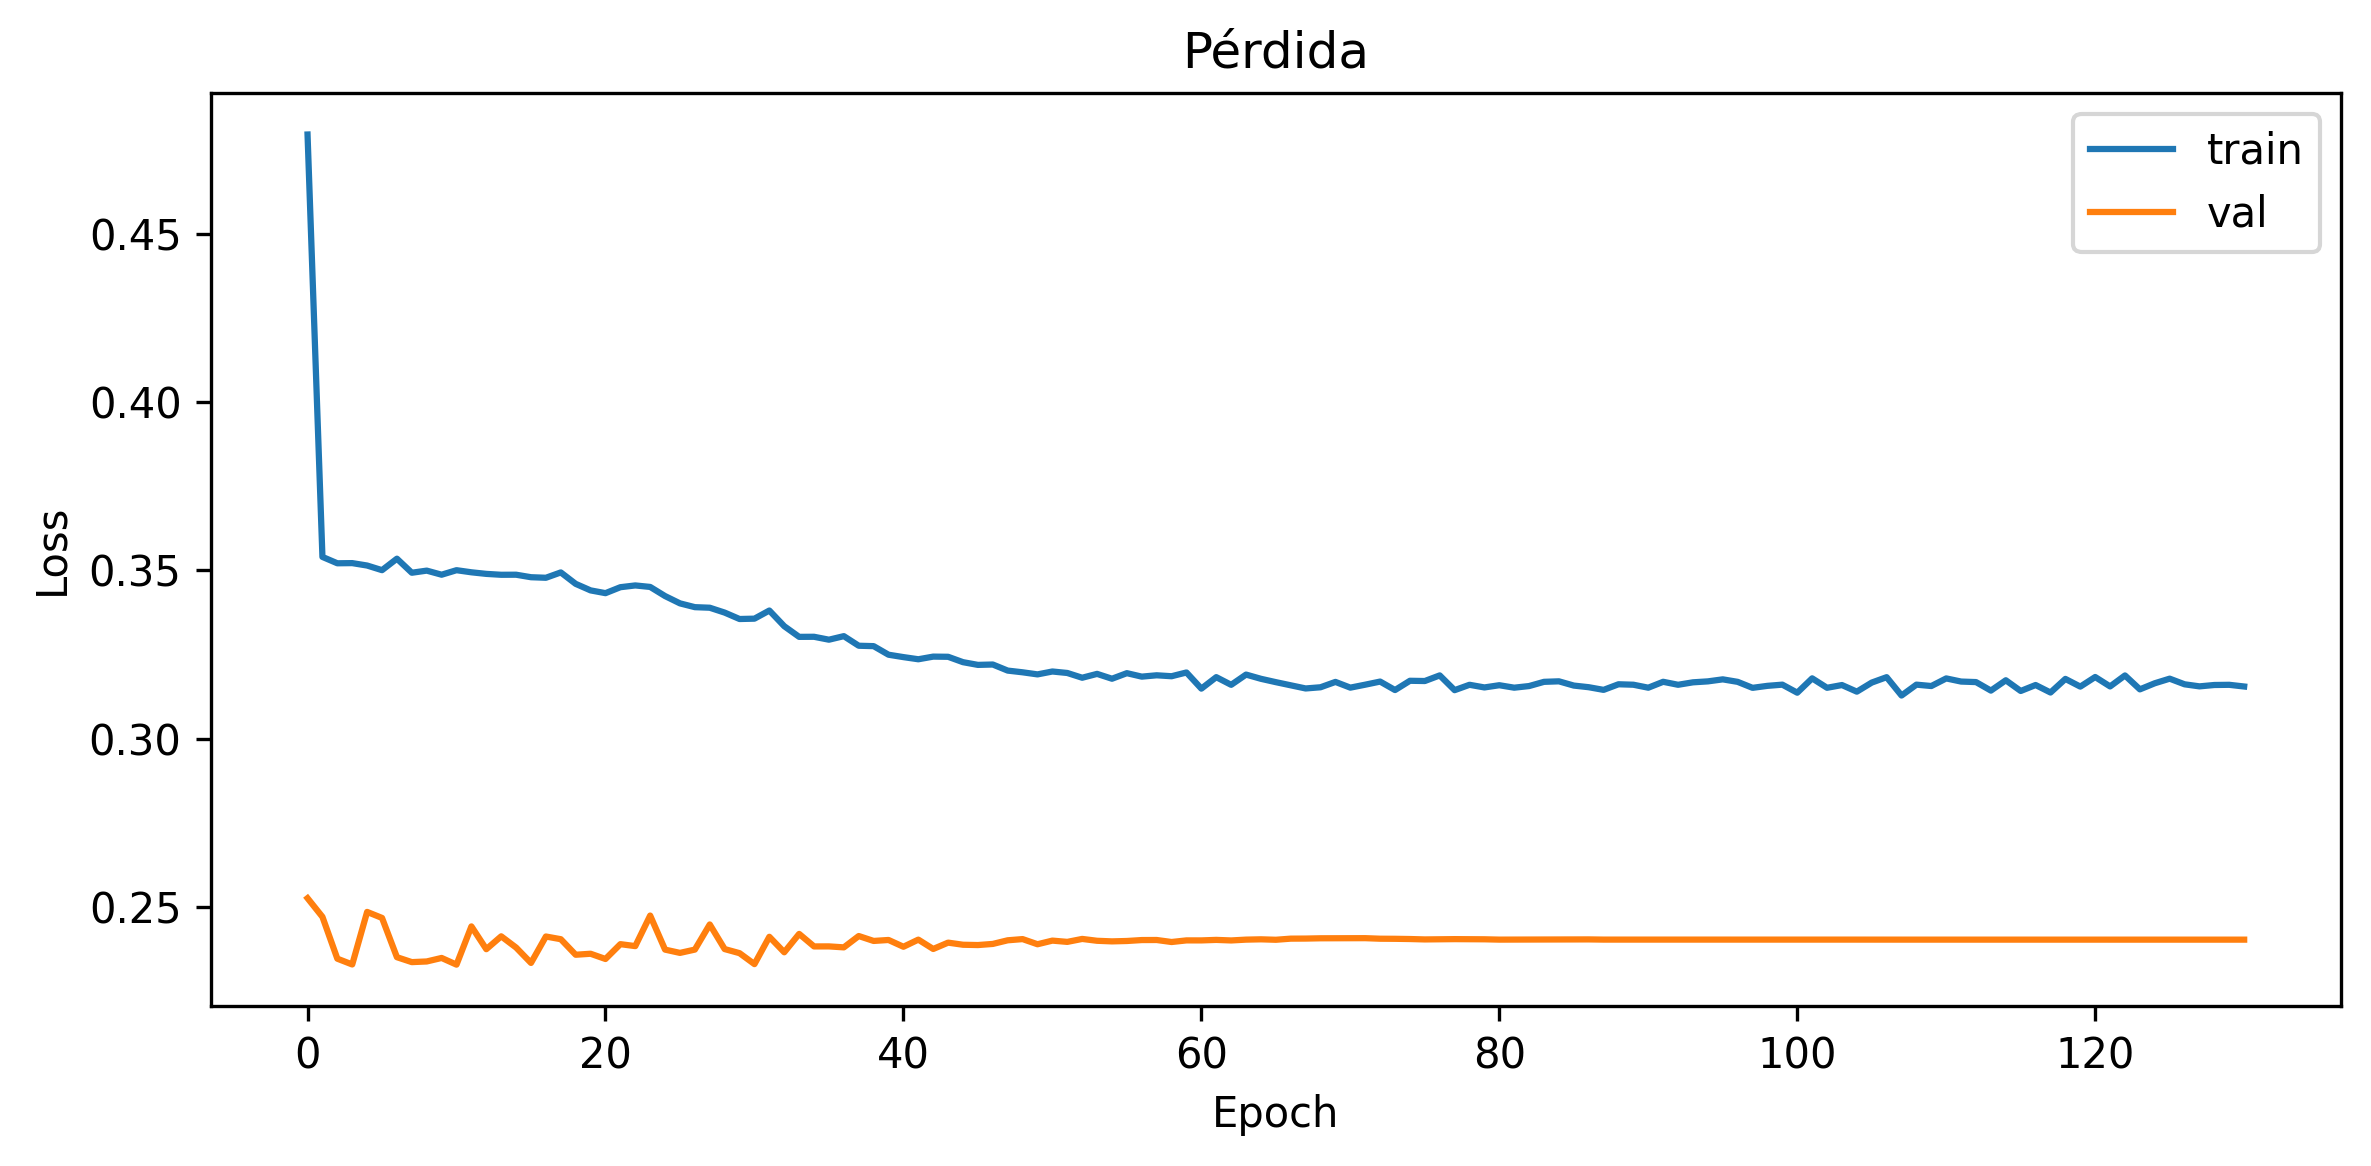

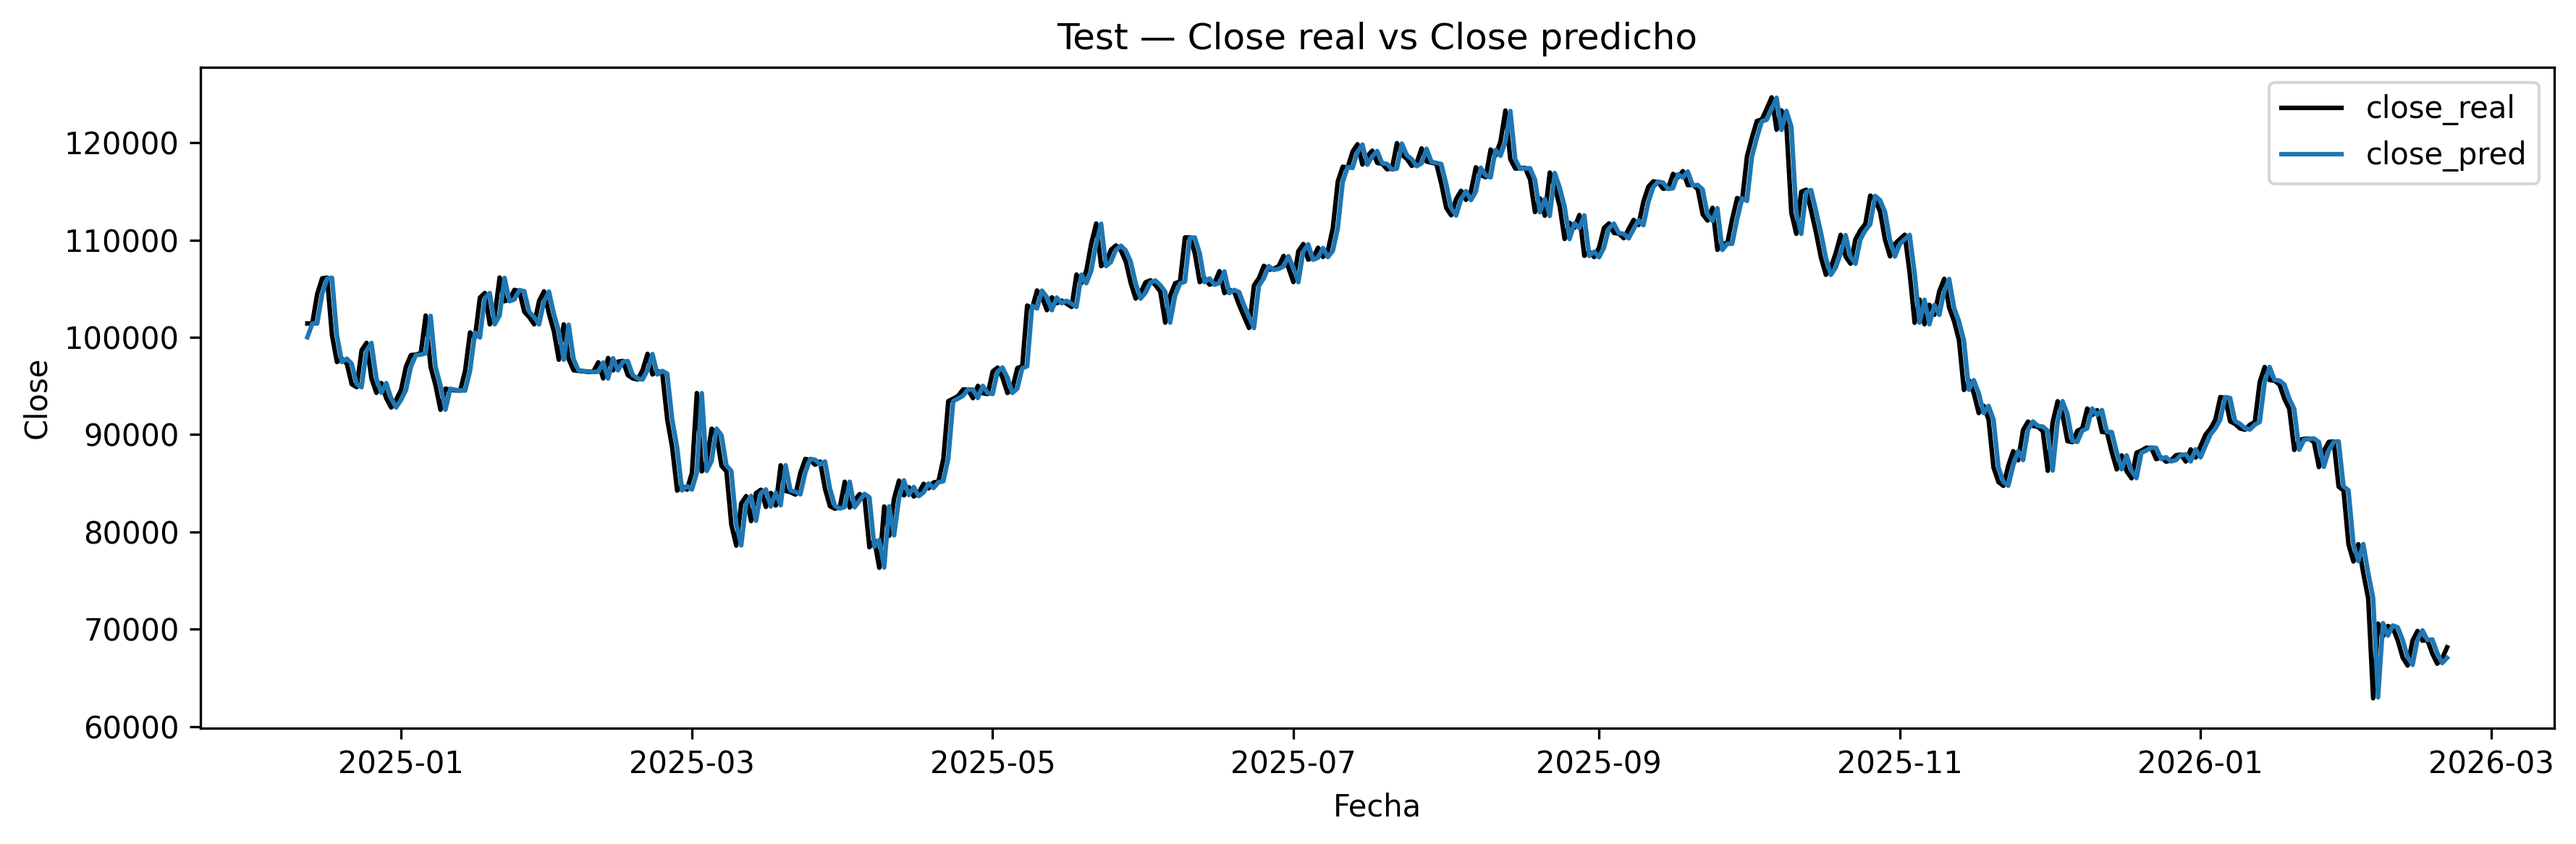

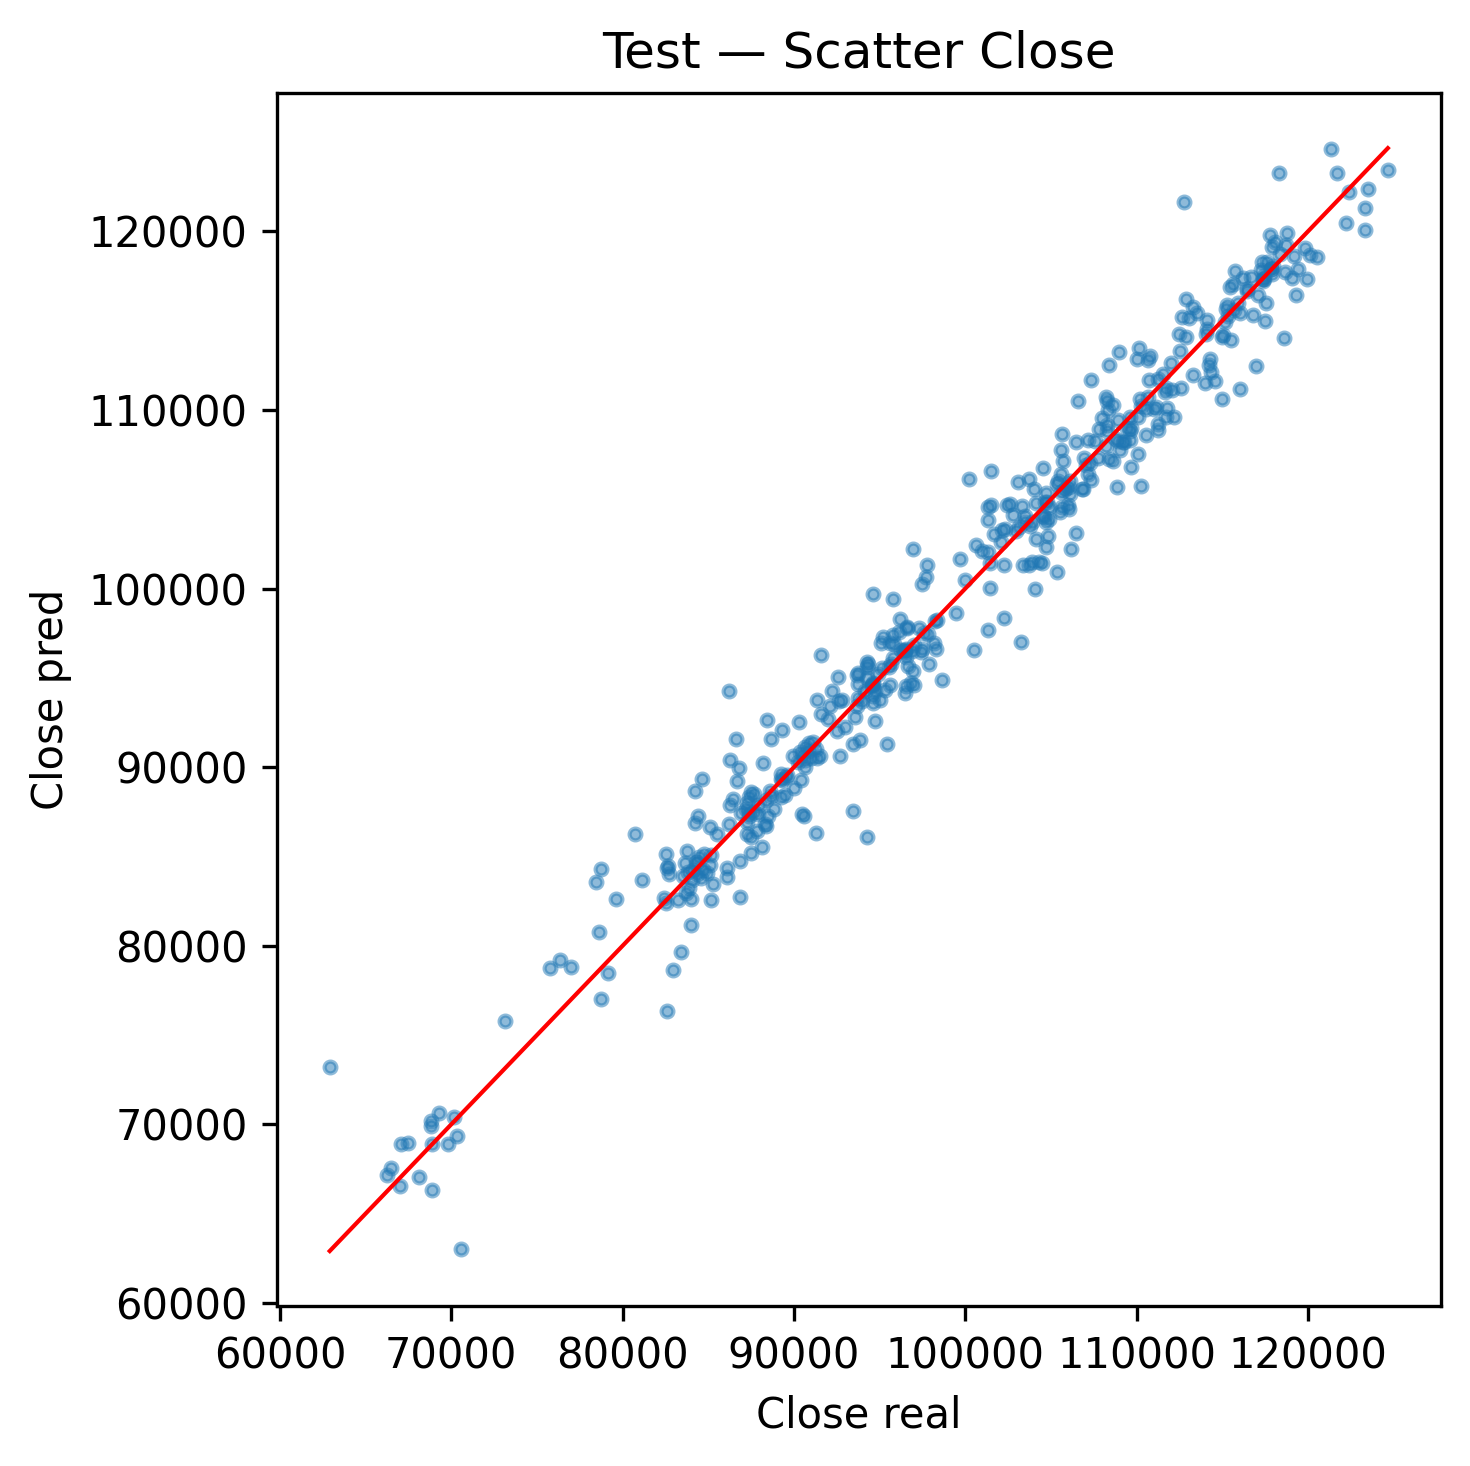

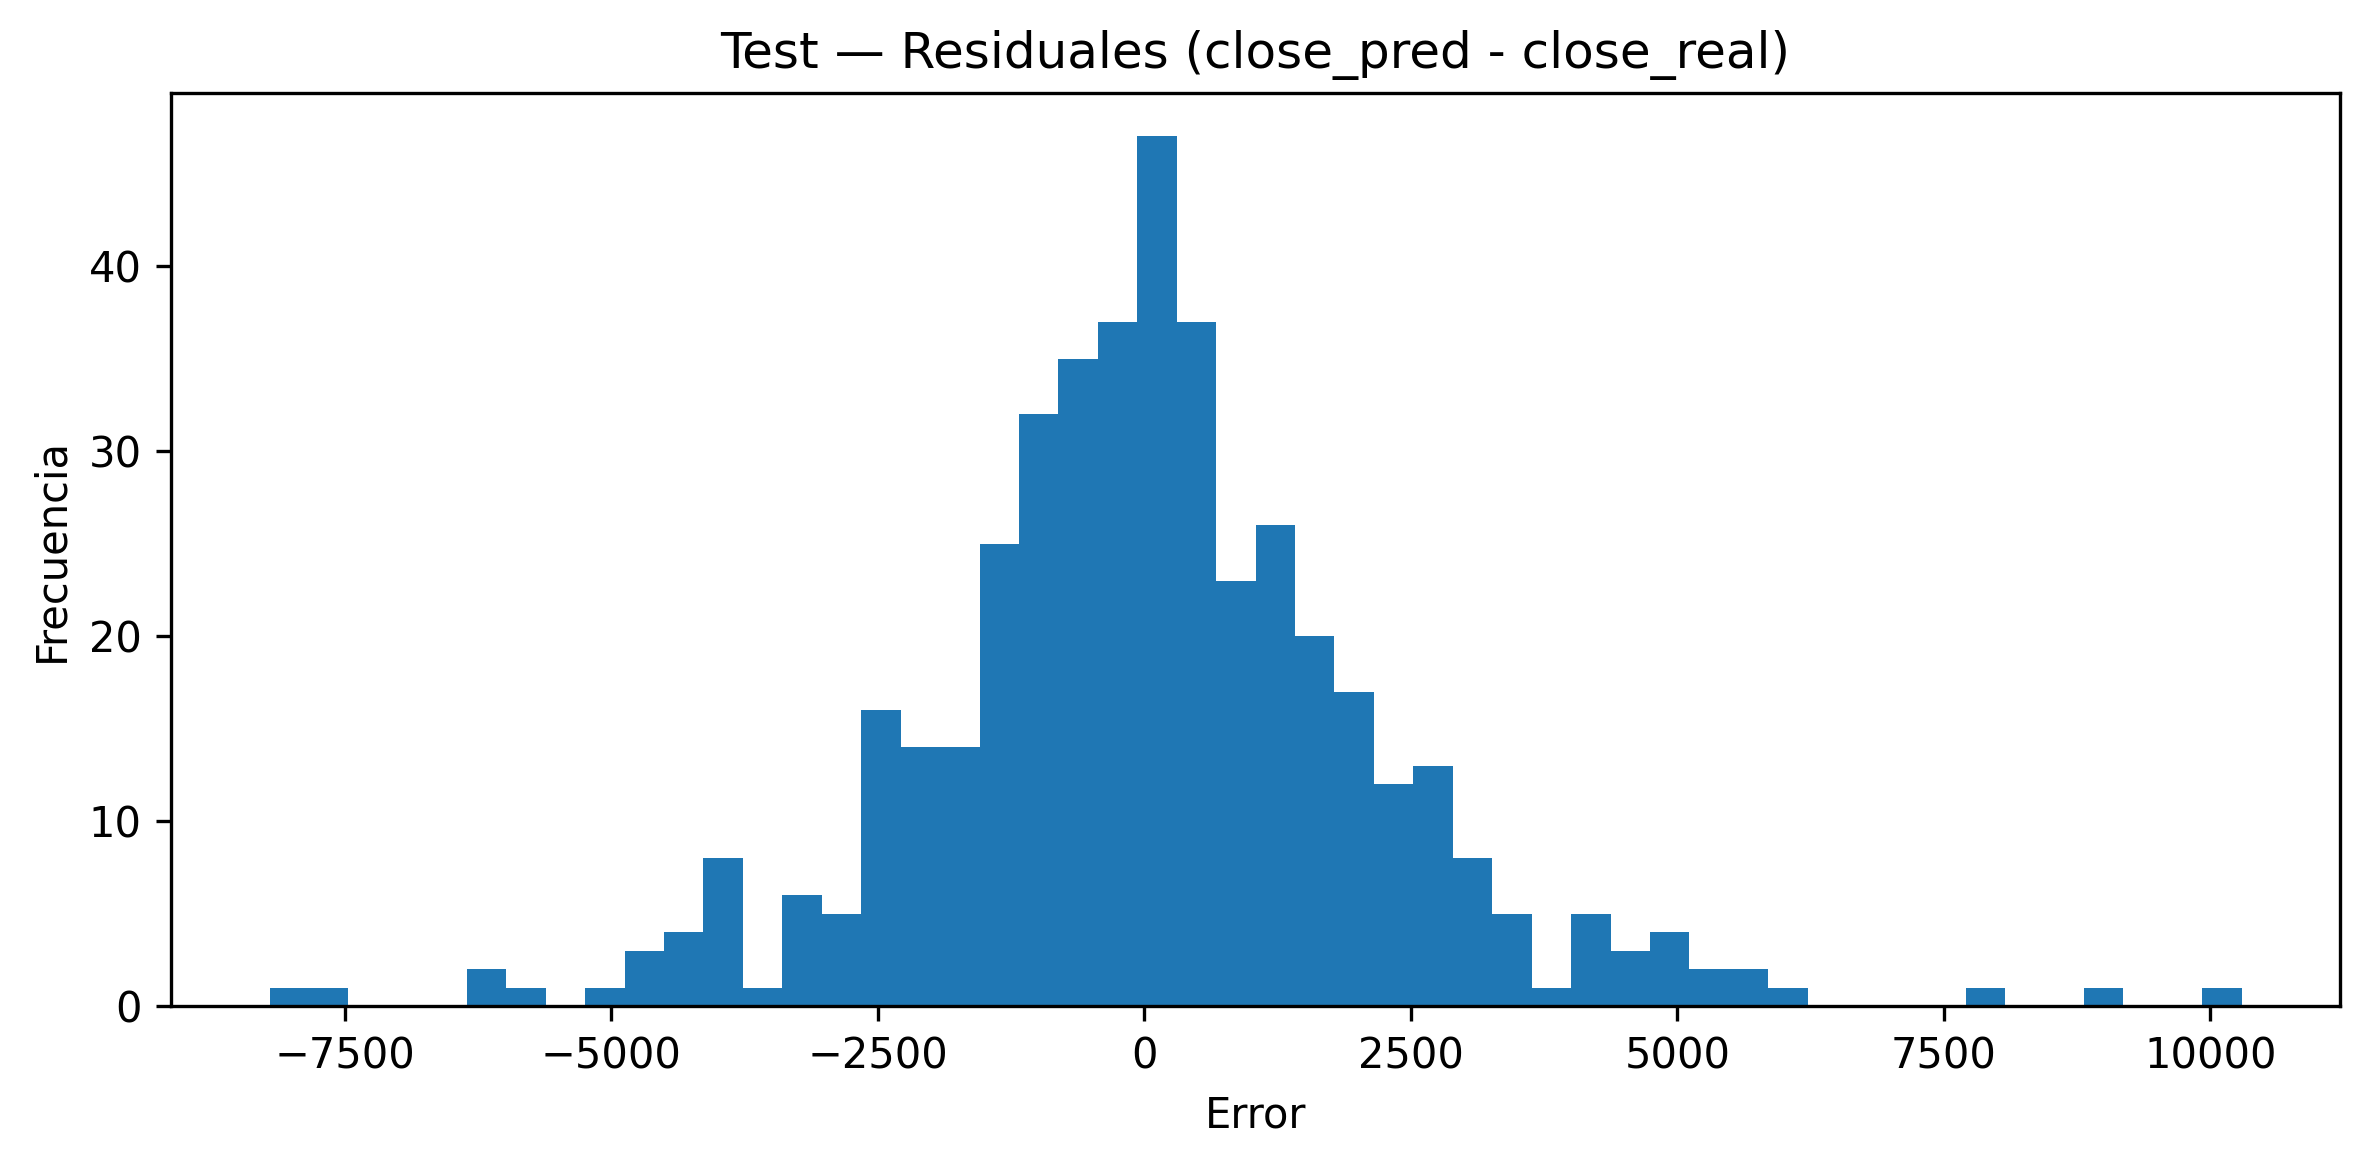

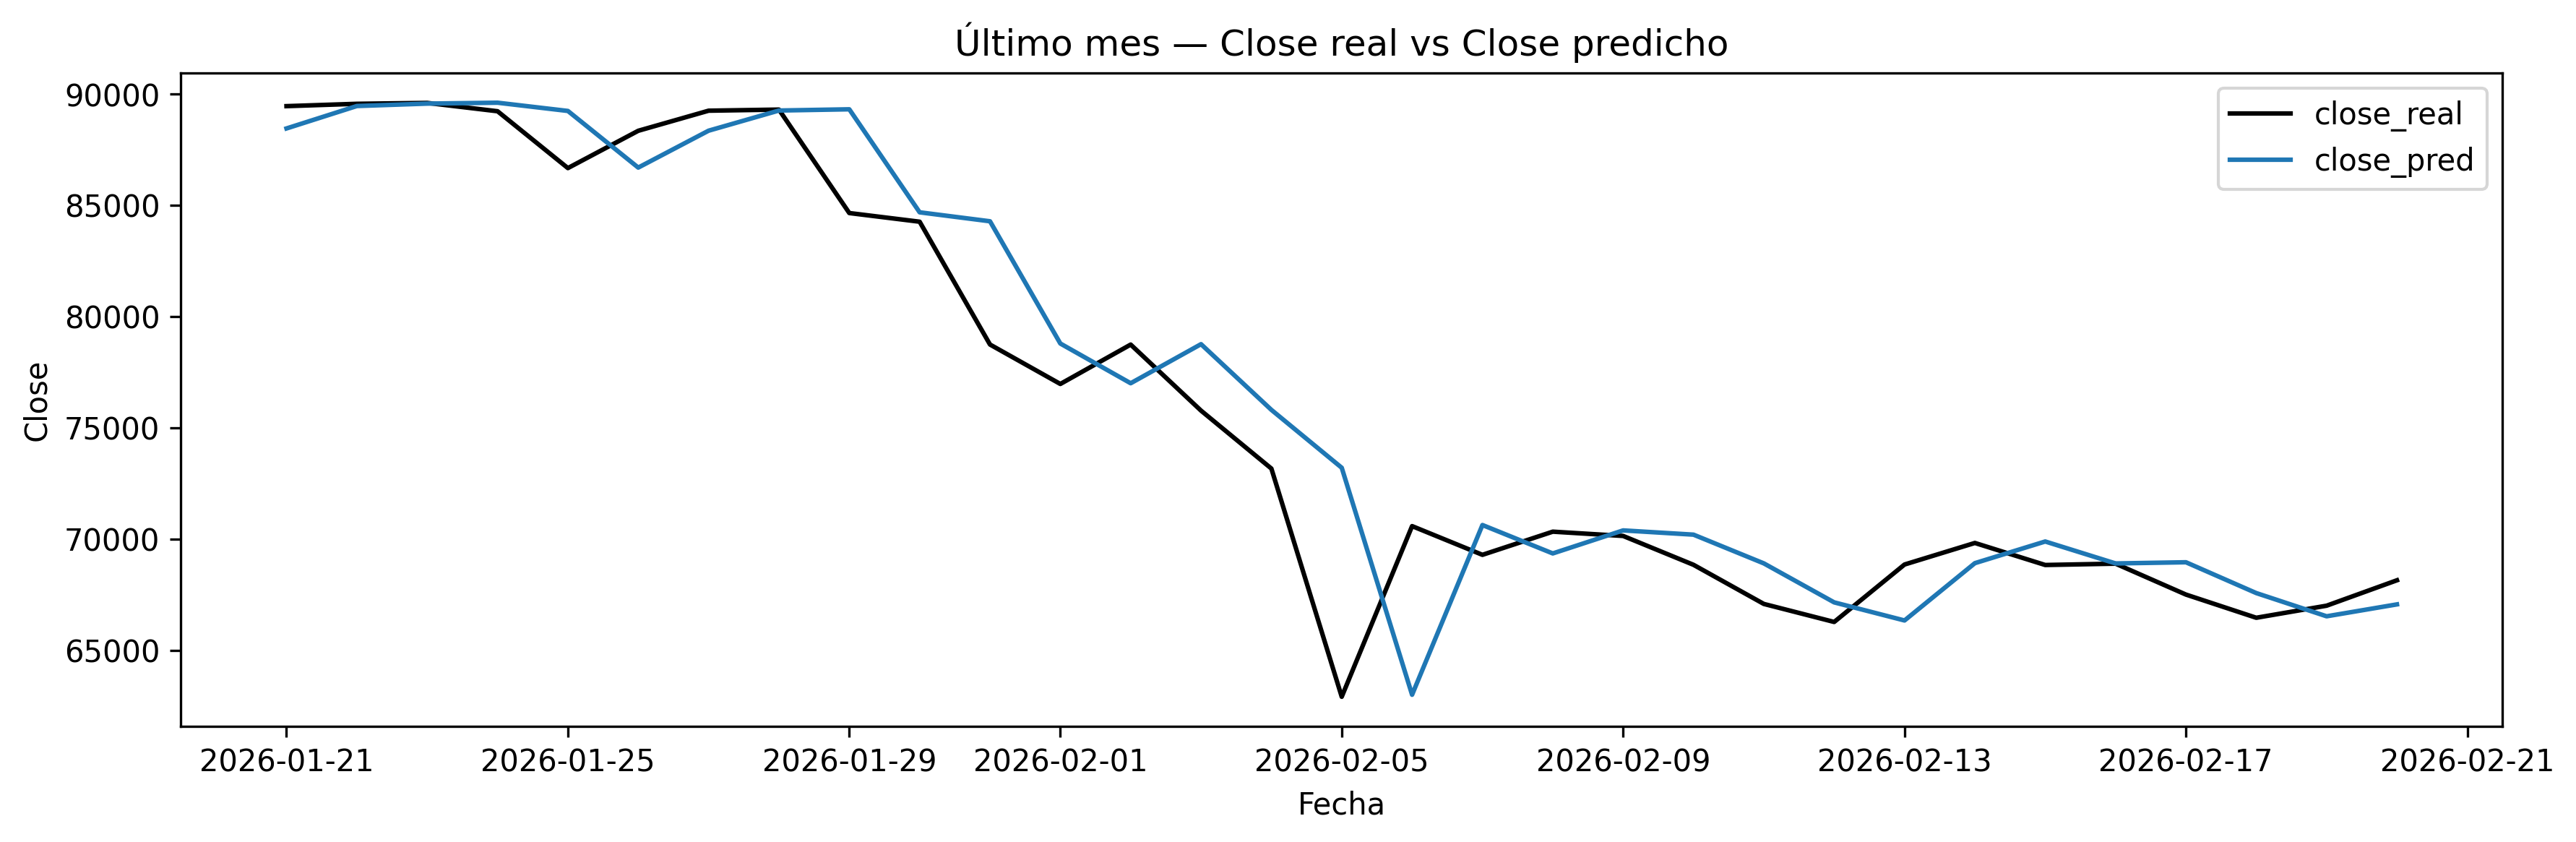

In [ ]:
from IPython.display import Image, display
fig_dir = pathlib.Path(result["figures_dir"])
for name in [
  "btc_transformer_close_train_val_loss.png",
  "btc_transformer_close_test_series.png",
  "btc_transformer_close_test_scatter.png",
  "btc_transformer_close_test_residuals.png",
  "btc_transformer_close_last_month_pred.png",
]:
  p = fig_dir / name
  if p.exists():
    display(Image(filename=str(p)))
